In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
import warnings
from scipy.optimize import least_squares
import numpy.linalg as la

In [2]:
data = {
    '45': {
        'time': np.array([0., 2., 4., 8., 16., 32., 64.]),
        'Al_f': np.array([0.57793934, 0.44606673, 0.35159301, 0.30447279,
                          0.19025257, 0.1190359, 0.0683903]),
        'Al_tot': 0.7539061007838296
    },
    '22': {
        'time': np.array([0., 1., 1.5, 2., 4., 6., 8., 12., 16., 22.]),
        'Al_f': np.array([1.06360903, 0.764354, 0.66100065, 0.62858508,
                          0.47474017, 0.37571418, 0.30535558, 0.22266848,
                          0.18058097, 0.1481312]),
        'Al_tot': 1.4662980027207297
    },
    '16': {
        'time': np.array([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 6.5, 10.75]),
        'Al_f': np.array([1.69098957, 0.8527369, 0.56334472, 0.4222341,
                          0.35084747, 0.28044497, 0.29166648, 0.25271929,
                          0.18129413, 0.1560142]),
        'Al_tot': 2.0613851873073203
    }
}

In [ ]:
def model(y, t, k1, k_1, k2):
    """
    Mechanism:
      Al_f → Al_ex + vac         (k1)
      Al_f + Al_ex → Al_fAl_ex   (k2)
    
    Species: [Al_f, Al_ex, Al_fAl_ex, Al_ex2, vac]
    """
    Al_f, Al_ex, Al_fAl_ex, vac = y
    
    r1  = k1 * Al_f           # Hydrolysis
    r_1 = k_1 * Al_ex * vac   # Reverse hydrolysis (insertion)
    r2  = k2 * Al_f * Al_ex   # Protonation
    
    dAl_f_dt = - r1 + r_1 - r2
    dAl_ex_dt = r1 - r_1 - r2    # Gain from hydrolysis, lose 2 per aggregation
    dAl_fAl_ex_dt = r2
    dvac_dt = r1 - r_1
    
    return [dAl_f_dt, dAl_ex_dt, dAl_fAl_ex_dt, dvac_dt]

In [ ]:
def simulate_model(params, sial_ratio):
    """Simulate hydrolysis + aggregation model"""
    k1, k_1, k2 = params

    exp_data = data[sial_ratio]
    Al_f0 = exp_data['Al_f'][0]

    y0 = [Al_f0, 0.0, 0.0, 0.0]
    t  = exp_data['time']

    try:
        solution = solve_ivp(
            fun=model,
            t_span=(t[0], t[-1]),       # integration interval
            y0=y0,
            method='Radau',             # stiff solver; 'BDF' is another option
            t_eval=t,                   # output at your experimental timepoints
            args=(k1, k_1, k2),
            rtol=1e-6,
            atol=1e-9,
            dense_output=False,
        )

        if not solution.success:        # solver can fail without raising
            return None, None, None

        Al_f_pred      = solution.y[0]  # shape: (n_timepoints,)
        Al_ex_pred     = solution.y[1]
        Al_fAl_ex_pred = solution.y[2]

        return Al_f_pred, Al_ex_pred, Al_fAl_ex_pred
    except Exception:
        return None, None, None

In [ ]:
def model(t, y, k1, k_1, k2):
    """
    Mechanism:
      Al_f <-> Al_ex + vac         (k1)
      2Al_ex -> Al_ex2            (k2)
    
    Species: [Al_f, Al_ex, Al_ex2, vac]
    """
    Al_f, Al_ex, Al_ex2, vac = y
    
    r1  = k1 * Al_f           # Hydrolysis
    r_1 = k_1 * Al_ex * vac   # Reverse hydrolysis (insertion)
    r2  = k2 * Al_ex**2       # Aggregation (2nd order)
    
    dAl_f_dt = - r1 + r_1
    dAl_ex_dt = r1 - r_1 - 2*r2    # Gain from hydrolysis, lose 2 per aggregation
    dAl_ex2_dt = r2
    dvac_dt = r1 - r_1
    
    return [dAl_f_dt, dAl_ex_dt, dAl_ex2_dt, dvac_dt]

In [ ]:
def simulate_model(params, sial_ratio):
    """Simulate hydrolysis + aggregation model"""
    k1, k_1, k2 = params

    exp_data = data[sial_ratio]
    Al_f0 = exp_data['Al_f'][0]

    y0 = [Al_f0, 0.0, 0.0, 0.0]
    t  = exp_data['time']

    try:
        solution = solve_ivp(
            fun=model,
            t_span=(t[0], t[-1]),       # integration interval
            y0=y0,
            method='Radau',             # stiff solver; 'BDF' is another option
            t_eval=t,                   # output at your experimental timepoints
            args=(k1, k_1, k2),
            rtol=1e-6,
            atol=1e-9,
            dense_output=False,
        )

        if not solution.success:        # solver can fail without raising
            return None, None, None

        Al_f_pred      = solution.y[0]  # shape: (n_timepoints,)
        Al_ex_pred     = solution.y[1]
        Al_ex2_pred = solution.y[2]

        return Al_f_pred, Al_ex_pred, Al_ex2_pred
    except Exception:
        return None, None, None

In [ ]:
def objective(params):
    """Fit aggregation model to all Si/Al data with GLOBAL k1, k2"""
    k1, k_1, k2 = params
    
    if k1 <= 0 or k_1 <= 0 or k2 <= 0:
        return 1e10
    
    total_error = 0
    
    for sial_ratio in ['16','22','45']:
        exp_data = data[sial_ratio]
        Al_f_exp = exp_data['Al_f']
        
        Al_f_pred, _, _ = simulate_model(params, sial_ratio)
        
        if Al_f_pred is None:
            return 1e10
        
        # Relative error
        rel_error = np.sum(((Al_f_pred - Al_f_exp) / Al_f_exp)**2)
        total_error += rel_error
    
    return total_error
    # return rel_error

In [ ]:
def callback(xk, convergence):
    fval = objective(xk)
    step = len(history) + 1
    history.append({
        "step": len(history) + 1,
        "fun": fval,
        "x": xk.copy(),
        "convergence": convergence
    })
    print(f"step={step:4d}  fun={fval:12.6e}  x={xk}  conv={convergence:.3e}")

# least_squares

In [3]:
def model(t, y, k1, km1, k2, Al_tot):
    Al_f, Al_ex = y
    vac = Al_tot - Al_f  # [*] = Al_tot - Al_f

    dAl_f  = -k1*Al_f + km1*Al_ex*vac
    dAl_ex =  k1*Al_f - km1*Al_ex*vac - 2.0*k2*(Al_ex**2)
    return np.array([dAl_f, dAl_ex], dtype=float)

In [4]:
def simulate_model(params, sial_ratio, rtol=1e-8, atol=1e-10):
    """
    params = (k1, km1, k2) all > 0
    Returns (Al_f_pred, Al_ex_pred) arrays aligned to data time points.
    """
    exp_data = data[sial_ratio]
    t_eval = exp_data['time']
    Al_tot = exp_data['Al_f'][0]

    # initial condition: Al_f(0)=Al_tot, Al_ex(0)=0
    y0 = np.array([Al_tot, 0.0], dtype=float)

    try:
        sol = solve_ivp(
            fun=lambda t, y: model(t, y, params[0], params[1], params[2], Al_tot),
            t_span=(float(t_eval[0]), float(t_eval[-1])),
            y0=y0,
            t_eval=t_eval,
            method='BDF',
            rtol=rtol,
            atol=atol
        )

        if (not sol.success) or np.any(~np.isfinite(sol.y)):
            return None, None

        return sol.y[0], sol.y[1]

    except Exception:
        return None, None

In [5]:
def params_to_log(params):
    k1, km1, k2 = np.asarray(params, dtype=float)
    return np.array([np.log10(k1), np.log10(km1), np.log10(k2)])

def log_to_params(logs):
    logk1, logkm1, logk2 = np.asarray(logs, dtype=float)
    return np.array([10**logk1, 10**logkm1, 10**logk2])

def residuals_logs(log, rtol=1e-8, atol=1e-10, penalty=1e3):
    params = log_to_params(log)
    res_list = []

    for sial in ['45', '22', '16']:
        Al_f_pred, Al_ex_pred = simulate_model(params, sial, rtol=rtol, atol=atol)
        Al_f_exp = data[sial]['Al_f']
        res_list.append(Al_f_pred - Al_f_exp)

    return np.concatenate(res_list)

In [15]:
# ---- choose a reasonable starting guess ----
# Example: start near k1=1, km1=1, k2=1 in your units
params0 = np.array([1, 1, 1], dtype=float)
logs0 = params_to_log(params0)

lb = np.array([-4, -4, -4], dtype=float)
ub = np.array([4,  4,  4], dtype=float)

res = least_squares(
    fun=lambda l: residuals_logs(l, rtol=1e-8, atol=1e-10),
    x0=logs0,
    bounds=(lb, ub),
    method="trf",
    jac="3-point",     # '3-point' more accurate than '2-point' citeturn0search1
    max_nfev=200       # increase if needed
)

log_hat = res.x
param_hat = log_to_params(log_hat)

print("Optimization success:", res.success)
print("Message:", res.message)
print("params_hat = [k1, km1, k2] =", param_hat)
print("SSE (sum of squared residuals):", 2.0 * res.cost)  # res.cost = 0.5*||r||^2

k1_opt, k_1_opt, k2_opt = param_hat

Optimization success: True
Message: `ftol` termination condition is satisfied.
params_hat = [k1, km1, k2] = [2.4568863  4.54231235 1.76236941]
SSE (sum of squared residuals): 0.9929955574970941


In [9]:
import numpy.linalg as la
def compute_degeneracy_metrics_from_ls_result(ls_result, eig_floor=1e-300):
    """
    Returns:
      J, A, eigvals, kappa(A), N(A)=log10(kappa(A))
    """
    J = np.asarray(ls_result.jac, dtype=float)  # shape: (m_residuals, n_params)

    A = J.T @ J

    # symmetric eigenvalues
    eigvals = la.eigvalsh(A)  # uses symmetry citeturn0search2
    eigvals = np.maximum(eigvals, eig_floor)

    kappa = float(eigvals.max() / eigvals.min())
    N_A = float(np.log10(kappa))

    return J, A, eigvals, kappa, N_A

In [10]:
J, A, eigvals, kappaA, NA = compute_degeneracy_metrics_from_ls_result(res)

print("Eigenvalues of A=J^T J:", eigvals)
print("Condition number kappa(A):", kappaA)
print("Degree of degeneracy N(A)=log10(kappa(A)):", NA)

Eigenvalues of A=J^T J: [3.01583090e-04 1.00737747e-01 1.46298579e+01]
Condition number kappa(A): 48510.20616605474
Degree of degeneracy N(A)=log10(kappa(A)): 4.68583312036075


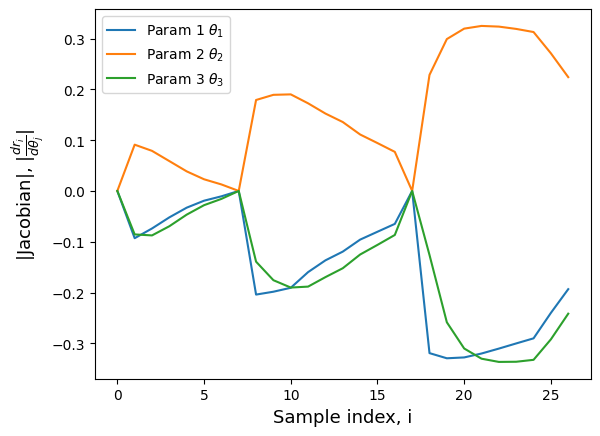

In [11]:
Jnorm = J / np.linalg.norm(J, axis=0, keepdims=True)
plt.plot(np.arange(len(Jnorm[:,0])),Jnorm[:,0],label=r'Param 1 $\theta_1$')
plt.plot(np.arange(len(Jnorm[:,0])),Jnorm[:,1],label=r'Param 2 $\theta_2$')
plt.plot(np.arange(len(Jnorm[:,0])),Jnorm[:,2],label=r'Param 3 $\theta_3$')
plt.xlabel('Sample index, i',fontsize=13)
plt.ylabel(r'|Jacobian|, $|\frac{dr_i}{d\theta_j}|$',fontsize=13)
plt.legend()

In [12]:
import numpy as np

def compute_covariance(result):
    """
    Compute covariance matrix from least_squares result.
    Cov = s^2 * (J^T J)^{-1}
    """
    J = result.jac                          # shape: (n_obs, n_params)
    residuals = result.fun                  # shape: (n_obs,)
    n_obs, n_params = J.shape

    SSR = np.sum(residuals**2)
    s2  = SSR / (n_obs - n_params)          # residual variance (unbiased)

    JtJ = J.T @ J                           # (3x3)

    try:
        cov = s2 * np.linalg.inv(JtJ)
    except np.linalg.LinAlgError:
        # JtJ is singular — use pseudoinverse as fallback
        cov = s2 * np.linalg.pinv(JtJ)
        print("Warning: JtJ was singular, used pseudoinverse.")

    return cov, s2

cov, s2 = compute_covariance(res)

# Standard errors (sqrt of diagonal)
std_errors = np.sqrt(np.diag(cov))
param_names = ['k1', 'k_1', 'k2']

print(f"Residual variance s² = {s2:.4e}\n")
print("Covariance matrix:")
print(cov)
print("\nStandard errors:")
for name, se in zip(param_names, std_errors):
    print(f"  {name}: ± {se:.4e}")

Residual variance s² = 4.1375e-02

Covariance matrix:
[[12.76384062 29.71615247 26.16082611]
 [29.71615247 69.64657416 61.75308905]
 [26.16082611 61.75308905 55.1952228 ]]

Standard errors:
  k1: ± 3.5727e+00
  k_1: ± 8.3455e+00
  k2: ± 7.4293e+00


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def cov_to_corr(cov):
    """Normalize covariance matrix to correlation matrix."""
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    return np.clip(corr, -1, 1)   # clip floating-point drift outside [-1,1]

corr = cov_to_corr(cov)

plt.figure(figsize=(5, 5))
param_names = ['k₁', 'k₋₁', 'k₂']

for ax, matrix, title, vmin in zip(
    axes,
    [cov,  corr],
    ['Covariance Matrix', 'Correlation Matrix'],
    [None, -1]
):
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.set_xticks(range(3)); ax.set_xticklabels(param_names, fontsize=12)
    plt.set_yticks(range(3)); ax.set_yticklabels(param_names, fontsize=12)
    plt.set_title(title, fontsize=13, fontweight='bold')
    
    # Annotate cells
    for i in range(3):
        for j in range(3):
            val = matrix[i, j]
            color = 'white' if abs(val) > 0.6 * (1 if vmin == -1 else np.max(np.abs(matrix))) else 'black'
            ax.text(j, i, f'{val:.3e}' if vmin is None else f'{val:.3f}',
                    ha='center', va='center', fontsize=10, color=color)


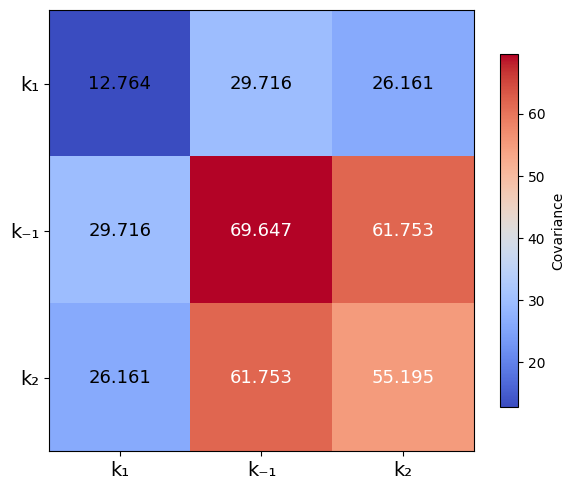

In [54]:
import matplotlib.pyplot as plt
import numpy as np

param_names = ['k₁', 'k₋₁', 'k₂']

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cov, cmap='coolwarm', aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Covariance')

ax.set_xticks(range(3)); ax.set_xticklabels(param_names, fontsize=14)
ax.set_yticks(range(3)); ax.set_yticklabels(param_names, fontsize=14)
# ax.set_title('Covariance Matrix', fontsize=13, fontweight='bold')

vmax = np.max(np.abs(cov))
for i in range(3):
    for j in range(3):
        val = cov[i, j]
        color = 'white' if abs(val) > 0.6 * vmax else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=13, color=color)

plt.tight_layout()
plt.savefig('covariance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

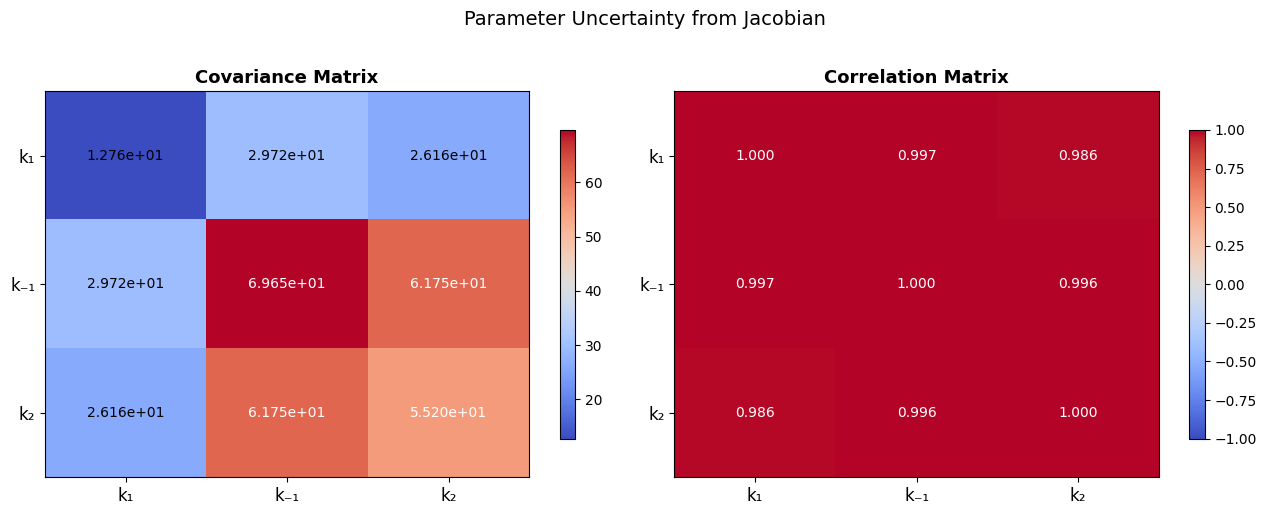

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def cov_to_corr(cov):
    """Normalize covariance matrix to correlation matrix."""
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    return np.clip(corr, -1, 1)   # clip floating-point drift outside [-1,1]

corr = cov_to_corr(cov)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
param_names = ['k₁', 'k₋₁', 'k₂']

for ax, matrix, title, vmin in zip(
    axes,
    [cov,  corr],
    ['Covariance Matrix', 'Correlation Matrix'],
    [None, -1]
):
    vmax = 1 if vmin == -1 else None
    im = ax.imshow(matrix, cmap='coolwarm', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(3)); ax.set_xticklabels(param_names, fontsize=12)
    ax.set_yticks(range(3)); ax.set_yticklabels(param_names, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')

    # Annotate cells
    for i in range(3):
        for j in range(3):
            val = matrix[i, j]
            color = 'white' if abs(val) > 0.6 * (1 if vmin == -1 else np.max(np.abs(matrix))) else 'black'
            ax.text(j, i, f'{val:.3e}' if vmin is None else f'{val:.3f}',
                    ha='center', va='center', fontsize=10, color=color)

plt.suptitle('Parameter Uncertainty from Jacobian', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('covariance_plot.png', dpi=150, bbox_inches='tight')
plt.show()

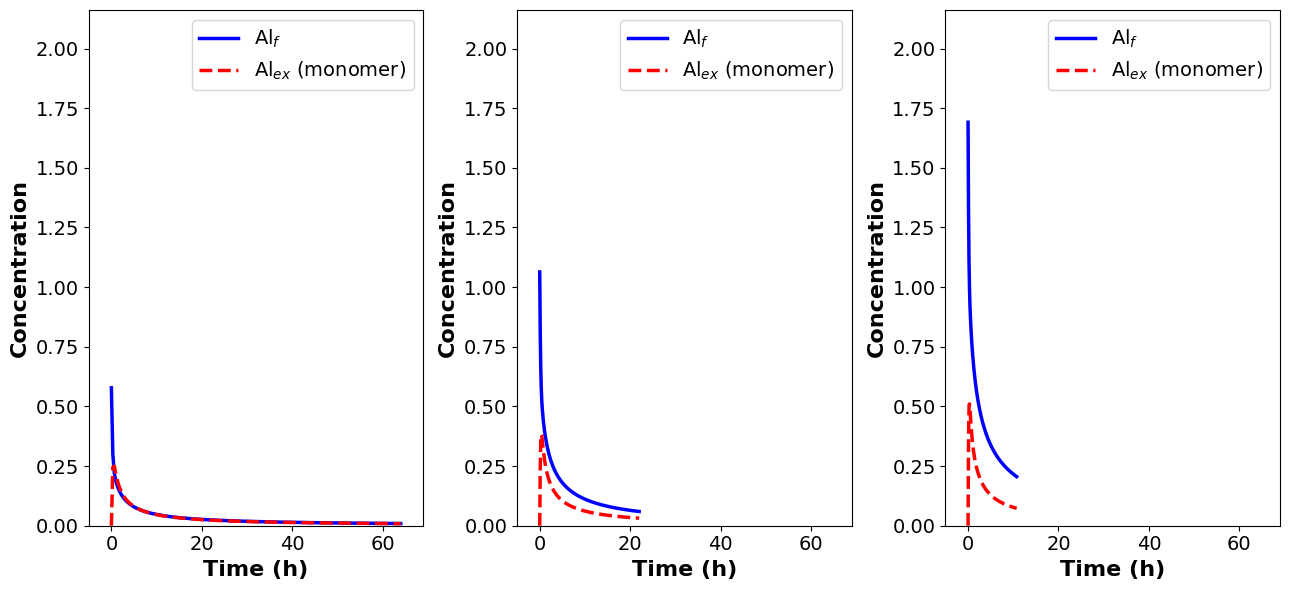

In [16]:
# Visualize fits
fig, axes = plt.subplots(1, 3, figsize=(13, 6))

model_prediction = {}
model_prediction['45']={}
model_prediction['22']={}
model_prediction['16']={}

for idx, sial_ratio in enumerate(['45', '22', '16']):
    exp_data = data[sial_ratio]
    t = exp_data['time']
    Al_f_exp = exp_data['Al_f']
    Al_f0 = Al_f_exp[0]
    Al_tot = exp_data['Al_f'][0]

    t_fine = np.linspace(0, t[-1], 200)
    y0 = [Al_f0, 0.0]
    sol = solve_ivp(
                fun=model,
                t_span=(t[0], t[-1]),       # integration interval
                y0=y0,
                method='Radau',             # stiff solver; 'BDF' is another option
                t_eval=t_fine,                   # output at your experimental timepoints
                args=(k1_opt, k_1_opt, k2_opt, Al_tot),
                rtol=1e-6,
                atol=1e-9
            )
    model_prediction[sial_ratio]['time']=sol.t
    model_prediction[sial_ratio]['Al_f']=sol.y[0]
    alf_pred = simulate_model(np.array([k1_opt, k_1_opt, k2_opt]), sial_ratio)[0]
    
    ax = axes[idx]
    ax.plot(t_fine, sol.y[0], '-', linewidth=2.5, label='Al$_f$', color='blue')
    ax.plot(t_fine, sol.y[1], '--', linewidth=2.5, label='Al$_{ex}$ (monomer)', color='red')
    # ax.plot(t_fine, sol.y[2], '-.', linewidth=2.5, label='Al$_{ex,2}$ (dimer)', color='black')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Concentration', fontsize=16, fontweight='bold')
    # ax.set_title('Species Evolution', fontsize=20, fontweight='bold')
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)
    # ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('aggregation_model_fit.png', dpi=300, bbox_inches='tight')
plt.show()

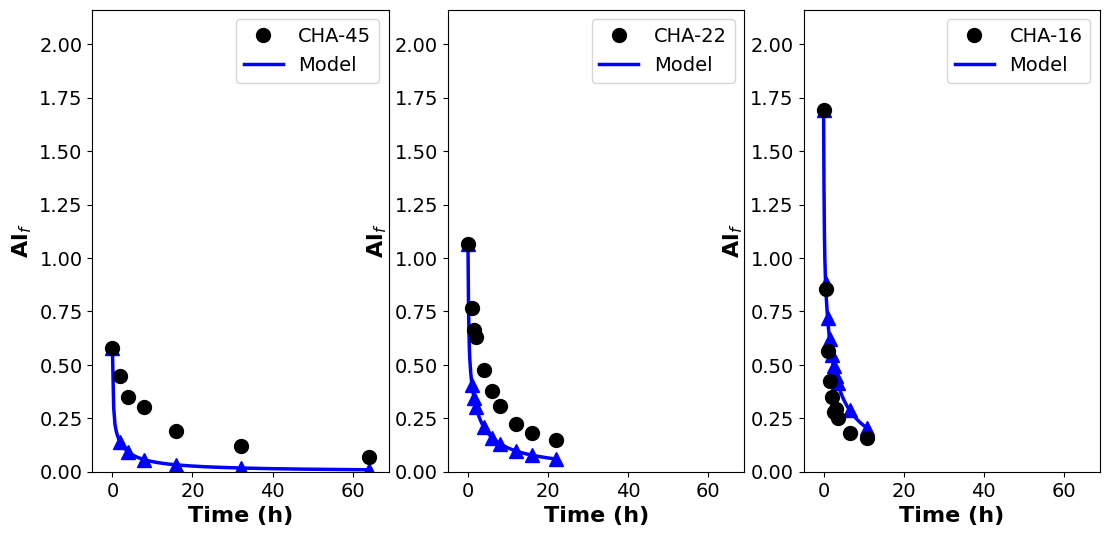

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 6))
for idx, sial_ratio in enumerate(['45', '22', '16']):
    exp_data = data[sial_ratio]
    t = exp_data['time']
    Al_f_exp = exp_data['Al_f']
    Al_f0 = Al_f_exp[0]
    alf_pred = simulate_model(np.array([k1_opt, k_1_opt, k2_opt]), sial_ratio)[0]
    ax = axes[idx]
    ax.plot(t, Al_f_exp, 'o', markersize=10, label=f'CHA-{sial_ratio}', color='black', zorder=5)
    ax.plot(model_prediction[sial_ratio]['time'],model_prediction[sial_ratio]['Al_f'], '-', linewidth=2.5, label='Model', color='blue')
    ax.plot(t, alf_pred, '^', markersize=10, color='blue')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Al$_f$', fontsize=16, fontweight='bold')
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)
    # ax.grid(True, alpha=0.3)

Half life in 45: 0.322
Half life in 22: 0.442
Half life in 16: 0.594


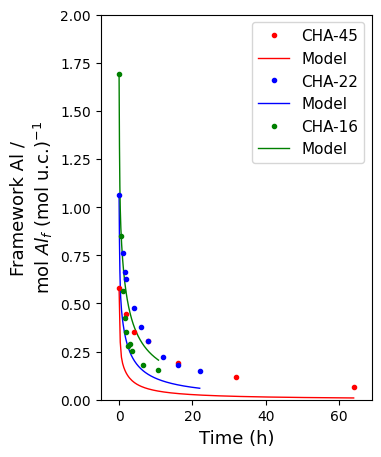

In [49]:
colors = {'45': 'r', '22': 'b', '16': 'g'}

plt.figure(figsize=(3.5, 5))
for idx, sial_ratio in enumerate(['45', '22', '16']):
    exp_data = data[sial_ratio]
    t = exp_data['time']
    Al_f_exp = exp_data['Al_f']
    Al_f0 = Al_f_exp[0]
    alf_pred = simulate_model(np.array([k1_opt, k_1_opt, k2_opt]), sial_ratio)[0]
    plt.plot(t, Al_f_exp, 'o', markersize=3, label=f'CHA-{sial_ratio}', color=colors[sial_ratio], zorder=5)
    plt.plot(model_prediction[sial_ratio]['time'],model_prediction[sial_ratio]['Al_f'], '-', linewidth=1, label='Model', color=colors[sial_ratio])
    idd = np.abs(model_prediction[sial_ratio]['Al_f']-model_prediction[sial_ratio]['Al_f'][0]/2).argmin()
    print(f'Half life in {sial_ratio}: {model_prediction[sial_ratio]['time'][idd]:.3f}')
    # plt.plot(t, alf_pred, '^', markersize=3, color=colors[sial_ratio])
plt.xlim(-5,data['45']['time'][-1]+5)
plt.ylim(0,2)
plt.xlabel('Time (h)', fontsize=13)
plt.ylabel('Framework Al /\nmol $Al_f$ (mol u.c.)$^{-1}$', fontsize=13)
# plt.tick_params(axis='x', labelsize=14, labelcolor='black')
# plt.tick_params(axis='y', labelsize=14, labelcolor='black')
plt.legend(fontsize=11)
    # ax.grid(True, alpha=0.3)

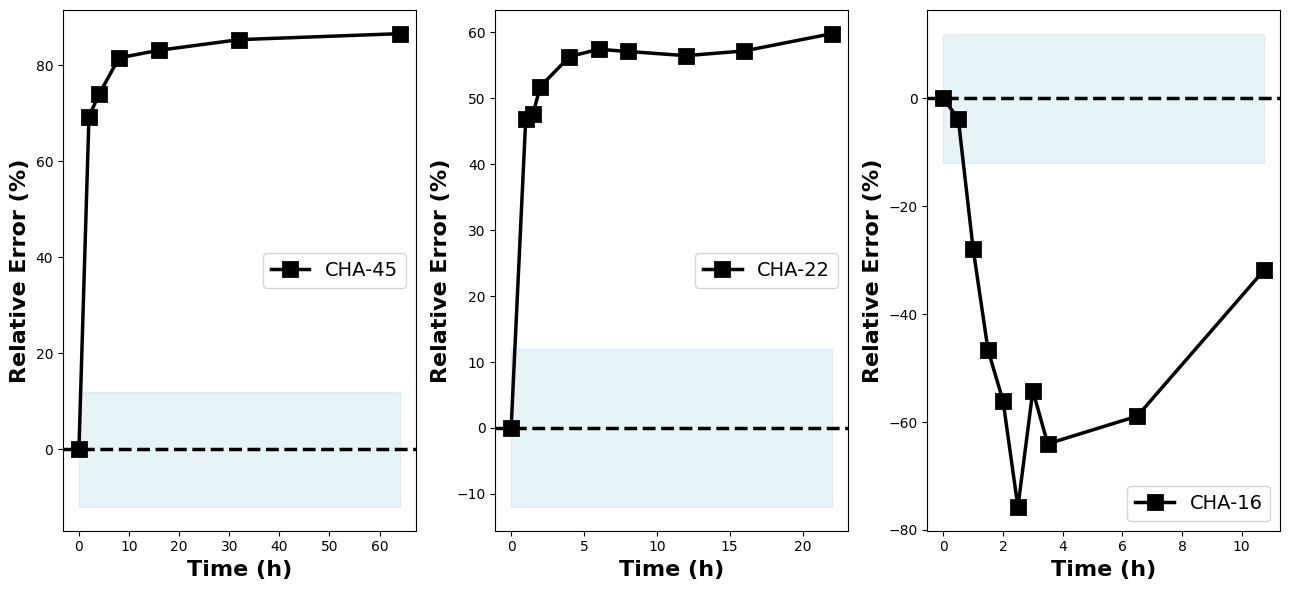


Si/Al      RMSE         MAE          MAPE (%)     Max |Error| (%)   
--------------------------------------------------------------------------------
45         0.194071     0.162344     68.56        86.60             
22         0.227117     0.197316     49.05        59.80             
16         0.146127     0.127219     41.92        75.76             

Average MAPE across all datasets: 53.18%
~ Acceptable fit (MAPE < 15%)



In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 6))

residual_stats = {}

for idx, sial_ratio in enumerate(['45', '22', '16']):
    exp_data = data[sial_ratio]
    t = exp_data['time']
    Al_f_exp = exp_data['Al_f']
    
    # Predict using aggregation model
    Al_f_pred, _ = simulate_model([k1_opt, k_1_opt, k2_opt], sial_ratio)
    
    # Calculate residuals
    residuals = Al_f_exp - Al_f_pred
    relative_residuals = (Al_f_exp - Al_f_pred) / Al_f_exp * 100  # Percentage
    
    # Calculate error metrics
    rmse = np.sqrt(np.mean(residuals**2))
    mae = np.mean(np.abs(residuals))
    mape = np.mean(np.abs(relative_residuals))
    max_abs_error = np.max(np.abs(relative_residuals))
    
    residual_stats[sial_ratio] = {
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'max_error': max_abs_error
    }
    
    # # Top row: Absolute residuals vs time
    # ax = axes[0, idx]
    # ax.plot(t, residuals, 'o-', markersize=10, linewidth=2.5, color='darkviolet',
    #         markerfacecolor='violet', markeredgewidth=2)
    # ax.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Zero error', zorder=1)
    # ax.fill_between(t, -0.05, 0.05, alpha=0.3, color='lightgreen', 
    #                  label='±0.05 threshold', zorder=0)
    
    # ax.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
    # ax.set_ylabel('Residual (Al$_f^{exp}$ - Al$_f^{pred}$)', fontsize=11, fontweight='bold')
    # ax.set_title(f'Si/Al = {sial_ratio}: Absolute Residuals', fontsize=13, fontweight='bold')
    # ax.legend(fontsize=9, loc='best')
    # ax.grid(True, alpha=0.4, linestyle='--')
    
    # # Add statistics box
    # textstr = f'RMSE: {rmse:.4f}\nMAE: {mae:.4f}'
    # props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    # ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
    #         verticalalignment='top', horizontalalignment='right', bbox=props)
    
    # Bottom row: Relative residuals vs time
    ax = axes[idx]
    ax.plot(t, relative_residuals, 's-', markersize=10, linewidth=2.5, color='black',
            markerfacecolor='black', markeredgewidth=2, label=f'CHA-{sial_ratio}')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=2.5, zorder=1)
    ax.fill_between(t, -12, 12, alpha=0.3, color='lightblue', zorder=0)
    # ax.fill_between(t, -10, 10, alpha=0.15, color='gray',
    #                  label='±10% error', zorder=0)
    
    ax.set_xlabel('Time (h)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Relative Error (%)', fontsize=16, fontweight='bold')
    # ax.set_title(f'Si/Al = {sial_ratio}: Relative Residuals', fontsize=16, fontweight='bold')
    ax.legend(fontsize=14, loc='best')
    # ax.grid(True, alpha=0.4, linestyle='--')
    
    # # Add statistics box
    # textstr = f'MAPE: {mape:.2f}%\nMax |Err|: {max_abs_error:.2f}%'
    # props = dict(boxstyle='round', facecolor='lightcyan', alpha=0.8)
    # ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=15,
    #         verticalalignment='top', horizontalalignment='right',bbox=props)

plt.tight_layout()
plt.savefig('validation_1_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'Si/Al':<10} {'RMSE':<12} {'MAE':<12} {'MAPE (%)':<12} {'Max |Error| (%)':<18}")
print("-"*80)
for sial_ratio in ['45', '22', '16']:
    stats = residual_stats[sial_ratio]
    print(f"{sial_ratio:<10} {stats['rmse']:<12.6f} {stats['mae']:<12.6f} "
          f"{stats['mape']:<12.2f} {stats['max_error']:<18.2f}")

# Overall assessment
avg_mape = np.mean([residual_stats[s]['mape'] for s in ['45', '22', '16']])
print(f"\nAverage MAPE across all datasets: {avg_mape:.2f}%")

if avg_mape < 5:
    print("✓✓ Excellent fit (MAPE < 5%)")
elif avg_mape < 10:
    print("✓ Good fit (MAPE < 10%)")
else:
    print("~ Acceptable fit (MAPE < 15%)")

print("\n" + "="*80)

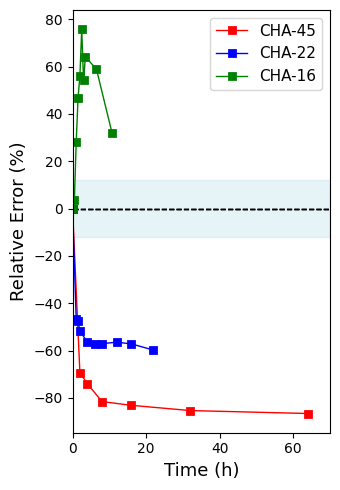

In [56]:
colors = {'45': 'r', '22': 'b', '16': 'g'}

plt.figure(figsize=(3.5, 5))

residual_stats = {}

for idx, sial_ratio in enumerate(['45', '22', '16']):
    exp_data = data[sial_ratio]
    t = exp_data['time']
    Al_f_exp = exp_data['Al_f']
    
    # Predict using aggregation model
    Al_f_pred, _ = simulate_model([k1_opt, k_1_opt, k2_opt], sial_ratio)
    
    # Calculate residuals
    residuals = Al_f_pred - Al_f_exp
    relative_residuals = (Al_f_pred-Al_f_exp ) / Al_f_exp * 100  # Percentage
    
    # Calculate error metrics
    rmse = np.sqrt(np.mean(residuals**2))
    mae = np.mean(np.abs(residuals))
    mape = np.mean(np.abs(relative_residuals))
    max_abs_error = np.max(np.abs(relative_residuals))
    
    residual_stats[sial_ratio] = {
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'max_error': max_abs_error
    }

    plt.plot(t, relative_residuals, 's-', markersize=4, linewidth=1, color=colors[sial_ratio],
            markerfacecolor=colors[sial_ratio], markeredgewidth=2, label=f'CHA-{sial_ratio}')
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1, zorder=1)
plt.fill_between((0,70), -12, 12, alpha=0.3, color='lightblue', zorder=0)


plt.xlabel('Time (h)', fontsize=13)
plt.ylabel('Relative Error (%)', fontsize=13)
plt.xlim(0,70)
plt.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('validation_1_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def integrated_rate_law(t, k_app, n, Al_f0):
    """
    Integrated rate law for -d[Al_f]/dt = k_app * [Al_f]^n
    
    For n ≠ 1: [Al_f]^(1-n) = [Al_f0]^(1-n) - k_app*(1-n)*t
    For n = 1: ln([Al_f]) = ln([Al_f0]) - k_app*t
    
    We use a smooth approximation near n=1 to avoid singularity
    """
    epsilon = 1e-6  # threshold for considering n ≈ 1
    
    if abs(n - 1) < epsilon:
        # First-order kinetics: [Al_f] = [Al_f0] * exp(-k_app*t)
        return Al_f0 * np.exp(-k_app * t)
    else:
        # General order kinetics
        term = Al_f0**(1-n) - k_app * (1-n) * t
        # Ensure we don't get negative values under the power
        term = np.maximum(term, 1e-10)
        return term**(1/(1-n))

# Fit each dataset
results = {}

for key, dataset in model_prediction.items():
    time = dataset['time']
    Al_f = dataset['Al_f']
    Al_f0 = Al_f[0]  # Initial concentration
    
    # Initial guesses: k_app ~ 0.01, n ~ 1 (first order)
    # We'll try multiple initial guesses to avoid local minima
    initial_guesses = [
        (1, 1.5, Al_f0),
        (1, 2, Al_f0),
        (1, 2.5, Al_f0)
    ]
    
    best_fit = None
    best_error = np.inf
    
    for guess in initial_guesses:
        try:
            # Fit the data
            popt, pcov = curve_fit(
                integrated_rate_law, 
                time, 
                Al_f, 
                p0=guess,
                bounds=([0, 0, Al_f0*0.9], [np.inf, 5, Al_f0*1.1]),
                maxfev=10000
            )
            
            # Calculate residual error
            predicted = integrated_rate_law(time, *popt)
            error = np.sum((Al_f - predicted)**2)
            
            if error < best_error:
                best_error = error
                best_fit = (popt, pcov)
        except:
            continue
    
    if best_fit is not None:
        popt, pcov = best_fit
        k_app, n, Al_f0_fit = popt
        
        # Calculate standard errors
        perr = np.sqrt(np.diag(pcov))
        
        # Calculate R²
        predicted = integrated_rate_law(time, *popt)
        ss_res = np.sum((Al_f - predicted)**2)
        ss_tot = np.sum((Al_f - np.mean(Al_f))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        results[key] = {
            'k_app': k_app,
            'n': n,
            'Al_f0': Al_f0_fit,
            'k_app_err': perr[0],
            'n_err': perr[1],
            'R2': r_squared
        }
        
        print(f"\n{'='*60}")
        print(f"Dataset: {key}")
        print(f"{'='*60}")
        print(f"Apparent rate constant (k_app): {k_app:.6f} ± {perr[0]:.6f}")
        print(f"Reaction order (n):              {n:.4f} ± {perr[1]:.4f}")
        print(f"Initial [Al_f]:                  {Al_f0_fit:.6f} ± {perr[2]:.6f}")
        print(f"R²:                              {r_squared:.6f}")
        
        # Classify order
        if abs(n - 1) < 0.1:
            order_type = "approximately first-order"
        elif abs(n - 2) < 0.1:
            order_type = "approximately second-order"
        elif abs(n - 0) < 0.1:
            order_type = "approximately zero-order"
        else:
            order_type = f"order {n:.2f}"
        print(f"Classification:                  {order_type}")

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (key, dataset) in enumerate(model_prediction.items()):
    time = dataset['time']
    Al_f = dataset['Al_f']
    
    if key in results:
        k_app = results[key]['k_app']
        n = results[key]['n']
        Al_f0 = results[key]['Al_f0']
        
        # Generate smooth curve
        t_smooth = np.linspace(0, time[-1], 100)
        Al_f_fit = integrated_rate_law(t_smooth, k_app, n, Al_f0)
        
        axes[idx].plot(time, Al_f, 'o', label='Data', markersize=8)
        axes[idx].plot(t_smooth, Al_f_fit, '-', label=f'Fit (n={n:.2f})', linewidth=2)
        axes[idx].set_xlabel('Time', fontsize=12)
        axes[idx].set_ylabel('[Al_f]', fontsize=12)
        axes[idx].set_title(f'Dataset {key}\nk_app={k_app:.4f}, n={n:.2f}', fontsize=12)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Extract results and organize data
datasets = ['45', '22', '16']
Al_tot_values = [data[key]['Al_tot'] for key in datasets]
k_app_values = [results[key]['k_app'] for key in datasets]
k_app_errors = [results[key]['k_app_err'] for key in datasets]
n_values = [results[key]['n'] for key in datasets]
n_errors = [results[key]['n_err'] for key in datasets]

exp_k_app_values=[np.float64(0.2843937683960249),
 np.float64(0.3579157123876951),
 np.float64(1.2106917445671188)]
exp_k_app_errors=[np.float64(0.06654404717395045),
 np.float64(0.021083520945710404),
 np.float64(0.06348515664058021)]
exp_n_values=[np.float64(2.2223652132086746),
 np.float64(2.2777734335510957),
 np.float64(2.295635065360914)]
exp_n_errors=[np.float64(0.20214631504815642),
 np.float64(0.09276706826033954),
 np.float64(0.11153885812494263)]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

# Plot 1: k_app vs [Al_tot]
ax1.errorbar(Al_tot_values, k_app_values, yerr=k_app_errors, 
             fmt='o--', color='tab:blue', markersize=12, linewidth=2.5, 
             capsize=6, capthick=2, elinewidth=2, label='Model')
ax1.errorbar(Al_tot_values, exp_k_app_values, yerr=exp_k_app_errors, 
             fmt='o--', color='tab:blue', alpha=0.5, markersize=12, linewidth=2.5, 
             capsize=6, capthick=2, elinewidth=2, label='Experiment')
ax1.set_xlabel('Initial Al Concentration, [Al$_{tot}$] (M)', fontsize=13)
ax1.set_ylabel('Apparent Rate Constant\n k$_{app}$ (M$^{1-n}$·time$^{-1}$)', fontsize=13)
ax1.tick_params(axis='both', labelsize=11)
ax1.legend(fontsize=10, loc='best')

# Plot 2: n vs [Al_tot]
ax2.errorbar(Al_tot_values, n_values, yerr=n_errors, 
             fmt='s--', color='tab:red', markersize=12, linewidth=2.5, 
             capsize=6, capthick=2, elinewidth=2,label='Model')
ax2.errorbar(Al_tot_values, exp_n_values, yerr=exp_n_errors, 
             fmt='s--', color='tab:red', alpha=0.5, markersize=12, linewidth=2.5, 
             capsize=6, capthick=2, elinewidth=2,label='Experiment')
ax2.set_xlabel('Initial Al Concentration, [Al$_{tot}$] (M)', fontsize=13)
ax2.set_ylabel('Reaction Order, n', fontsize=13)
ax2.tick_params(axis='both', labelsize=11)

# Add reference line at n=2
ax2.axhline(y=2.0, color='gray', linestyle=':', linewidth=2, alpha=0.5, label='n = 2')
ax2.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()